# Homework 5 - Submission
## - Soham Sarkar (sxs210586)


# CS 6307 — Big Data Management & Analytics
## Homework 5 · Part 1: Spark Structured Streaming with NewsAPI & Kafka

### Pipeline Overview
```
NewsAPI  ──►  Kafka topic1  ──►  PySpark Structured Streaming (NER)  ──►  Kafka topic2  ──►  Matplotlib bar charts
```
**Your tasks (marked `### TODO`):**
1. Implement the **NewsAPI → Kafka producer**
2. Implement the **PySpark Structured Streaming NER job**
3. Implement the **consumer + Matplotlib visualizations**

The Kafka broker setup in Section 0 is provided for you — do not modify it.


---
## Section 0 — Environment Setup (PROVIDED — do not modify)
Install dependencies, start Kafka, and create the two topics.


In [ ]:
# ── Install Python dependencies ──────────────────────────────────────────────
!pip install -q newsapi-python kafka-python pyspark spacy
!python -m spacy download en_core_web_sm -q
print("✓ Python dependencies installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 39.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✓ Python dependencies installed


In [ ]:
# ── Install Java (required by PySpark) ───────────────────────────────────────
!apt-get install -y -q openjdk-17-jdk-headless
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
!java -version


Reading package lists...
Building dependency tree...
Reading state information...
openjdk-17-jdk-headless is already the newest version (17.0.18+8-1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [ ]:
# ── Download Kafka ────────────────────────────────────────────────────────────
import subprocess, os, shutil

KAFKA_VERSION = "3.7.1"
KAFKA_DIR     = f"kafka_2.13-{KAFKA_VERSION}"
KAFKA_TGZ     = f"{KAFKA_DIR}.tgz"
KAFKA_URL     = f"https://archive.apache.org/dist/kafka/{KAFKA_VERSION}/{KAFKA_TGZ}"

if os.path.exists(KAFKA_DIR) and not os.path.exists(f"{KAFKA_DIR}/bin/kafka-storage.sh"):
    shutil.rmtree(KAFKA_DIR)

if not os.path.exists(KAFKA_DIR):
    print("Downloading Kafka…")
    ret = subprocess.run(f"wget -q {KAFKA_URL}", shell=True)
    if ret.returncode != 0:
        raise RuntimeError(f"Download failed: {KAFKA_URL}")
    subprocess.run(f"tar -xzf {KAFKA_TGZ}", shell=True, check=True)
    print(f"✓ Kafka {KAFKA_VERSION} extracted")
else:
    print(f"✓ Kafka {KAFKA_VERSION} already present")


✓ Kafka 3.7.1 extracted


In [ ]:
# ── Start Kafka broker (KRaft mode — no Zookeeper) ───────────────────────────
import subprocess, time

KAFKA_DIR = "kafka_2.13-3.7.1"

cluster_id = subprocess.check_output(
    f"bash {KAFKA_DIR}/bin/kafka-storage.sh random-uuid", shell=True
).decode().strip()

subprocess.run(
    f"{KAFKA_DIR}/bin/kafka-storage.sh format "
    f"--config {KAFKA_DIR}/config/kraft/server.properties "
    f"--cluster-id {cluster_id} --ignore-formatted",
    shell=True, check=True, capture_output=True
)

broker = subprocess.Popen(
    f"{KAFKA_DIR}/bin/kafka-server-start.sh "
    f"{KAFKA_DIR}/config/kraft/server.properties",
    shell=True,
    stdout=open("kafka.log", "w"),
    stderr=subprocess.STDOUT,
)

print("Waiting for Kafka broker…")
time.sleep(10)

for topic in ["topic1", "topic2"]:
    subprocess.run(
        f"{KAFKA_DIR}/bin/kafka-topics.sh --create --if-not-exists "
        f"--bootstrap-server localhost:9092 "
        f"--replication-factor 1 --partitions 1 --topic {topic}",
        shell=True, capture_output=True
    )

result = subprocess.check_output(
    f"{KAFKA_DIR}/bin/kafka-topics.sh --list --bootstrap-server localhost:9092",
    shell=True
).decode()
print("Topics:", result.strip())
print("✓ Kafka broker running on localhost:9092")


Waiting for Kafka broker…
Topics: topic1
topic2
✓ Kafka broker running on localhost:9092


---
## Section 1 — NewsAPI → Kafka Producer

**Your job:** Complete the three `### TODO` blocks below.

The producer should:
- Accept `--api-key`, `--query`, `--bootstrap-servers`, `--topic`, `--interval`, `--page-size` as CLI args
- Fetch articles from NewsAPI (English, sorted by `publishedAt`)
- Combine title + description + content into a single `text` field
- Skip duplicate URLs across cycles
- Send each article as a JSON message to `topic1`
- Sleep `--interval` seconds between fetches and loop indefinitely

> Get a free NewsAPI key at https://newsapi.org/register (100 req/day on free tier)


In [ ]:
# Q1. Part A - NewsAPI --> Kafka Producer (generate newsapi_to_kafka.py)

import os

# ── Set your NewsAPI key ──────────────────────────────────────────────────────
os.environ["NEWSAPI_KEY"] = ""   # ← paste your key
NEWS_QUERY = "technology"                              # ← change to any topic

if os.environ["NEWSAPI_KEY"] == "YOUR_NEWSAPI_KEY_HERE":
    raise ValueError("Please replace YOUR_NEWSAPI_KEY_HERE with your actual NewsAPI key!")

print(f"✓ Key configured. Query: {repr(NEWS_QUERY)}")


✓ Key configured. Query: 'technology'


In [ ]:
producer_code = '''
"""
newsapi_to_kafka.py
-------------------
Fetches live news from NewsAPI and sends each article to a Kafka topic.
"""
import argparse, json, os, signal, sys, time
import requests
from kafka import KafkaProducer
from kafka.errors import NoBrokersAvailable


def parse_args():
    p = argparse.ArgumentParser(description="NewsAPI -> Kafka producer")
    p.add_argument("--api-key",           default=os.getenv("NEWSAPI_KEY"))
    p.add_argument("--query",             default="technology")
    p.add_argument("--bootstrap-servers", default="localhost:9092")
    p.add_argument("--topic",             default="topic1")
    p.add_argument("--interval",          type=int, default=60)
    p.add_argument("--page-size",         type=int, default=20)
    p.add_argument("--max-cycles",        type=int, default=0)  # 0 = infinite
    return p.parse_args()


def make_producer(bootstrap_servers, retries=10):
    ### TODO (1 of 3):
    for attempt in range(retries):
        try:
            return KafkaProducer(
                bootstrap_servers=bootstrap_servers,
                value_serializer=lambda v: json.dumps(v).encode("utf-8"),
                acks="all",
                retries=5
            )
        except NoBrokersAvailable:
            if attempt < retries - 1:
                time.sleep(5)
            else:
                raise RuntimeError("All retries exhausted. No brokers available.")


def fetch_articles(api_key, query, page_size):
    ### TODO (2 of 3):
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": query,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size,
        "apiKey": api_key
    }
    res = requests.get(url, params=params)
    data = res.json()
    if data.get("status") != "ok":
        raise RuntimeError(f"NewsAPI error: {data.get('message')}")
    return data.get("articles", [])


def main():
    args = parse_args()
    if not args.api_key:
        sys.exit("[producer] ERROR: --api-key is required.")

    producer = make_producer(args.bootstrap_servers)

    running = True
    def _handle_sigint(sig, frame):
        nonlocal running
        running = False
    signal.signal(signal.SIGINT, _handle_sigint)

    seen_urls  = set()
    total_sent = 0
    cycle      = 0

    print(f"[producer] query={args.query!r} -> topic={args.topic!r}")

    while running:
        cycle += 1
        if args.max_cycles and cycle > args.max_cycles:
            break
        try:
            ### TODO (3 of 3):
            articles = fetch_articles(args.api_key, args.query, args.page_size)
            for art in articles:
                url = art.get("url")
                if not url or url in seen_urls:
                    continue
                seen_urls.add(url)
                title = art.get("title") or ""
                desc = art.get("description") or ""
                content = art.get("content") or ""
                # Build full text and handle empties
                full_text = f"{title}. {desc}. {content}".strip()
                if not full_text or full_text == ". .":
                    continue
                msg = {
                    "url": url,
                    "source": art.get("source", {}).get("name", ""),
                    "text": full_text,
                    "publishedAt": art.get("publishedAt", ""),
                    "query": args.query
                }
                producer.send(args.topic, msg)
                total_sent += 1
            producer.flush()
            print(f"[producer] Cycle {cycle}: total unique articles sent so far = {total_sent}")
        except Exception as exc:
            print(f"[producer] ERROR cycle {cycle}: {exc}", file=sys.stderr)
        if running:
            time.sleep(args.interval)

    producer.close()
    print(f"[producer] Done. Total sent: {total_sent}")


if __name__ == "__main__":
    main()
'''

with open("newsapi_to_kafka.py", "w") as f:
    f.write(producer_code)

import subprocess
res = subprocess.run(["python", "-m", "py_compile", "newsapi_to_kafka.py"],
                     capture_output=True, text=True)
print("✓ Producer file saved" if res.returncode == 0 else "✗ Syntax error:\n" + res.stderr)


✓ Producer file saved


In [ ]:
# ── Launch producer in background ────────────────────────────────────────────
import subprocess, os

producer_proc = subprocess.Popen(
    [
        "python", "newsapi_to_kafka.py",
        "--api-key",           os.environ.get("NEWSAPI_KEY", ""),
        "--query",             NEWS_QUERY,
        "--bootstrap-servers", "localhost:9092",
        "--topic",             "topic1",
        "--interval",          "60",
        "--page-size",         "20",
    ],
    stdout=open("producer.log", "w"),
    stderr=subprocess.STDOUT,
)
print(f"✓ Producer started (PID {producer_proc.pid}). Logs → producer.log")


✓ Producer started (PID 76137). Logs → producer.log


In [ ]:
# ── Verify topic1 is receiving messages ──────────────────────────────────────
import time
time.sleep(15)
KAFKA_DIR = "kafka_2.13-3.7.1"
!{KAFKA_DIR}/bin/kafka-console-consumer.sh \
    --bootstrap-server localhost:9092 \
    --topic topic1 --from-beginning \
    --max-messages 3 --timeout-ms 10000


{"url": "https://cryptobriefing.com/tim-cook-warns-of-rising-memory-costs-amid-us-china-tensions/", "source": "Crypto Briefing", "text": "Tim Cook warns of rising memory costs amid US-China tensions. Rising memory costs amid US-China tensions could strain tech profit margins, potentially reshaping market cap leadership dynamics.\nThe post Tim Cook warns of rising memory costs amid US-China tensions appeared first on Crypto Briefing.. ## Market Snapshot\r\nThe market predicting whether NVIDIA will be the largest company by market cap on June 30 is currently priced at 65.5% for a YES outcome. The prediction for May 31 stands at 78.2%\u2026 [+2354 chars]", "publishedAt": "2026-05-01T00:34:57Z", "query": "technology"}
{"url": "https://www.livemint.com/industry/manufacturing/rising-govt-spending-export-demand-give-indian-defence-cos-15trn-runway-11777542780819.html", "source": "Livemint", "text": "Rising govt spending, export demand give Indian defence cos \u20b915trn runway. The top five d

---
## Section 2 — PySpark Structured Streaming NER Job

**Your job:** Complete the four `### TODO` blocks inside `spark_ner_streaming.py`.

The job should:
- Read JSON messages from `topic1` (schema: `url`, `source`, `text`, `publishedAt`, `query`)
- Apply a spaCy UDF to extract named entities from the `text` field  
  (keep entity types: `PERSON`, `ORG`, `GPE`, `LOC`, `NORP`, `EVENT`, `PRODUCT`, `LAW`)
- Maintain a **running count** of (entity, label) pairs across all batches
- At each trigger, write the **top-10** entities as JSON messages to `topic2`  
  with schema `{entity, label, count, window_end, batch_id}`
- Use `outputMode("complete")` and a `foreachBatch` sink

**Hint:** Use `spark.readStream.format("kafka")`, `F.from_json`, `F.explode`, `groupBy(...).count()`.


In [ ]:
# Q1. Part B - PySpark Structured Streaming NER Job (generate spark_ner_streaming.py)

import shutil

CHECKPOINT = "/tmp/assign3_ner_checkpoint"
shutil.rmtree(CHECKPOINT, ignore_errors=True)

spark_code = '''
"""
spark_ner_streaming.py
Reads from topic1, extracts named entities, writes top-10 counts to topic2.
"""
import argparse
from datetime import datetime, timezone
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StringType, StructField, StructType


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--bootstrap-servers", default="localhost:9092")
    p.add_argument("--input-topic",       default="topic1")
    p.add_argument("--output-topic",      default="topic2")
    p.add_argument("--checkpoint",        default="/tmp/ner_checkpoint")
    p.add_argument("--trigger-seconds",   type=int, default=60)
    return p.parse_args()


# ── spaCy NER UDF ─────────────────────────────────────────────────────────────
_NLP = None

ENTITY_SCHEMA = ArrayType(
    StructType([
        StructField("entity", StringType(), False),
        StructField("label",  StringType(), False),
    ])
)

def _extract_entities(text):
    ### TODO (1 of 4):
    global _NLP
    if _NLP is None:
        import spacy
        # Lazy-load spaCy model on the worker nodes
        _NLP = spacy.load("en_core_web_sm")
    if not text:
        return []
    doc = _NLP(text[:512])
    valid_types = {"PERSON", "ORG", "GPE", "LOC", "NORP", "EVENT", "PRODUCT", "LAW"}
    entities = []
    for ent in doc.ents:
        clean_text = ent.text.strip()
        if ent.label_ in valid_types and len(clean_text) > 1:
            entities.append((clean_text, ent.label_))
    return entities


# ── foreachBatch callback ─────────────────────────────────────────────────────
def batch_to_kafka(batch_df, batch_id, output_topic, bootstrap_servers):
    if batch_df.rdd.isEmpty():
        return

    window_end = datetime.now(timezone.utc).isoformat()

    ### TODO (2 of 4):
    kafka_df = batch_df.select(
        F.to_json(F.struct(
            F.col("entity"),
            F.col("label"),
            F.col("count"),
            F.lit(window_end).alias("window_end"),
            F.lit(batch_id).alias("batch_id")
        )).cast("binary").alias("value")
    )
    kafka_df.write.format("kafka") \
        .option("kafka.bootstrap.servers", bootstrap_servers) \
        .option("topic", output_topic) \
        .save()

    # Print top-10 to stdout for monitoring
    top10 = batch_df.orderBy(F.col("count").desc()).limit(10).collect()
    print(f"\\n[batch {batch_id}] Top-10 entities ({window_end})")
    for row in top10:
        print(f"  {row['entity']:<40} [{row['label']:<8}] count={row['count']}")


# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    args = parse_args()

    spark = (
        SparkSession.builder
        .appName("CS6307_NER_Streaming")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")

    ner_udf = spark.udf.register("extract_ents", _extract_entities, ENTITY_SCHEMA)

    ### TODO (3 of 4):
    schema = StructType([
        StructField("url", StringType()),
        StructField("source", StringType()),
        StructField("text", StringType()),
        StructField("publishedAt", StringType()),
        StructField("query", StringType())
    ])
    raw_stream = spark.readStream.format("kafka") \
        .option("kafka.bootstrap.servers", args.bootstrap_servers) \
        .option("subscribe", args.input_topic) \
        .load()
    parsed_stream = raw_stream.select(
        F.from_json(F.col("value").cast("string"), schema).alias("data")
    ).select("data.*")
    filtered_stream = parsed_stream.filter(F.col("text").isNotNull())
    with_ents = filtered_stream.withColumn("ents", ner_udf(F.col("text"))) \
        .withColumn("ent", F.explode(F.col("ents"))) \
        .select(F.col("ent.entity").alias("entity"), F.col("ent.label").alias("label"))

    ### TODO (4 of 4):
    counts = with_ents.groupBy("entity", "label").count()
    query = counts.writeStream \
        .outputMode("complete") \
        .trigger(processingTime=f"{args.trigger_seconds} seconds") \
        .option("checkpointLocation", args.checkpoint) \
        .foreachBatch(lambda df, epoch_id: batch_to_kafka(df, epoch_id, args.output_topic, args.bootstrap_servers)) \
        .start()
    query.awaitTermination()


if __name__ == "__main__":
    main()
'''

with open("spark_ner_streaming.py", "w") as f:
    f.write(spark_code)

res = __import__("subprocess").run(
    ["python", "-m", "py_compile", "spark_ner_streaming.py"],
    capture_output=True, text=True
)
print("✓ Spark script saved" if res.returncode == 0 else "✗ Syntax error:\n" + res.stderr)


✓ Spark script saved


In [ ]:
# ── Submit the Spark streaming job ───────────────────────────────────────────
import subprocess

spark_proc = subprocess.Popen(
    [
        "spark-submit",
        "--packages", "org.apache.spark:spark-sql-kafka-0-10_2.13:4.0.0",
        "spark_ner_streaming.py",
        "--bootstrap-servers", "localhost:9092",
        "--input-topic",       "topic1",
        "--output-topic",      "topic2",
        "--checkpoint",        "/tmp/assign3_ner_checkpoint",
        "--trigger-seconds",   "60",
    ],
    stdout=open("spark_streaming.log", "w"),
    stderr=subprocess.STDOUT,
)
print(f"✓ Spark job started (PID {spark_proc.pid}). Logs → spark_streaming.log")


✓ Spark job started (PID 76625). Logs → spark_streaming.log


In [ ]:
# ── Wait for first trigger then tail logs ─────────────────────────────────────
import time
print("Waiting 75s for first Spark trigger…")
time.sleep(75)
print("=== spark_streaming.log (last 20 lines) ===")
!tail -n 20 spark_streaming.log


Waiting 75s for first Spark trigger…
=== spark_streaming.log (last 20 lines) ===
26/05/02 00:36:29 INFO Executor: Fetching spark://de7ebca37882:42933/jars/org.slf4j_slf4j-api-2.0.16.jar with timestamp 1777682185817
26/05/02 00:36:29 INFO Utils: Fetching spark://de7ebca37882:42933/jars/org.slf4j_slf4j-api-2.0.16.jar to /tmp/spark-601491d0-797c-44ef-94eb-cd58cb75c817/userFiles-0b7c4669-24f3-4572-a31c-5ddf5083e78d/fetchFileTemp14544249706807206063.tmp
26/05/02 00:36:29 INFO Utils: /tmp/spark-601491d0-797c-44ef-94eb-cd58cb75c817/userFiles-0b7c4669-24f3-4572-a31c-5ddf5083e78d/fetchFileTemp14544249706807206063.tmp has been previously copied to /tmp/spark-601491d0-797c-44ef-94eb-cd58cb75c817/userFiles-0b7c4669-24f3-4572-a31c-5ddf5083e78d/org.slf4j_slf4j-api-2.0.16.jar
26/05/02 00:36:29 INFO Executor: Adding file:/tmp/spark-601491d0-797c-44ef-94eb-cd58cb75c817/userFiles-0b7c4669-24f3-4572-a31c-5ddf5083e78d/org.slf4j_slf4j-api-2.0.16.jar to class loader default
26/05/02 00:36:29 INFO Executor: 

#---
## Section 3 — Consumer & Matplotlib Visualizations

**Your job:** Complete the two `### TODO` blocks below.

- `fetch_top10()`: read all messages from `topic2`, keep the **latest count per entity**,
  and return the top-10 sorted by count descending.
- `plot_top10()`: draw a **horizontal bar chart** with:
  - entity names on the Y-axis
  - cumulative mention count on the X-axis
  - bars colored by entity type (use the `palette` dict provided)
  - a legend showing entity types
  - title including the NewsAPI query and snapshot interval label

Snapshots are taken at **15, 30, 45, and 60 minutes**.  
Save each chart as `top10_entities_{N}min.png`.


Waiting 15 minutes for the pipeline to process the first batch of news...



-- Snapshot @ 15 min --


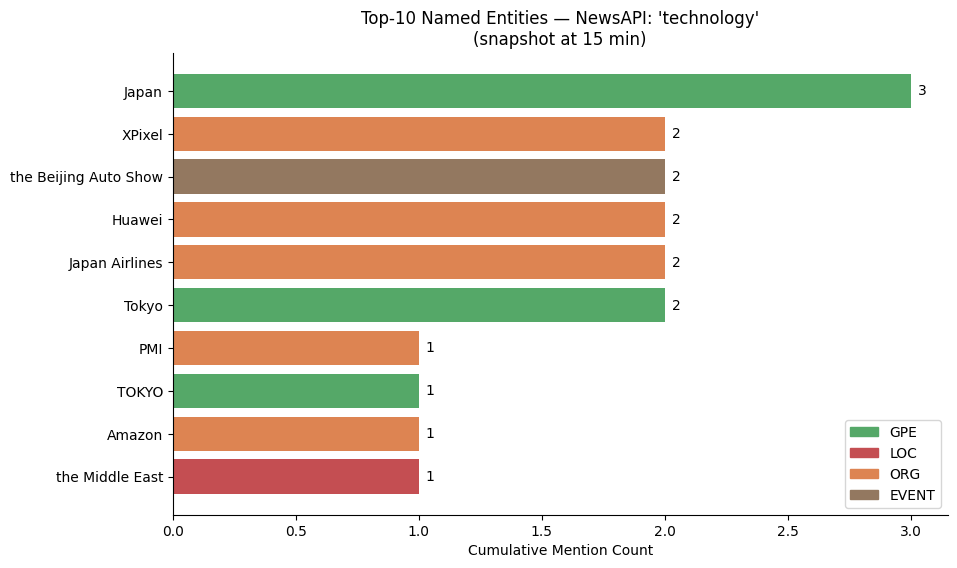

Waiting 15 min for next snapshot…



-- Snapshot @ 30 min --


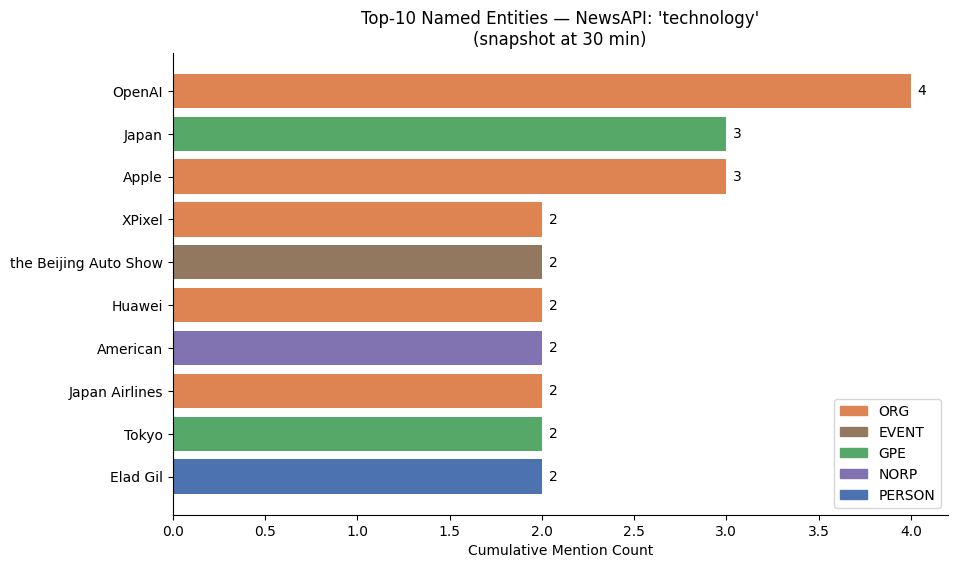

Waiting 15 min for next snapshot…



-- Snapshot @ 45 min --


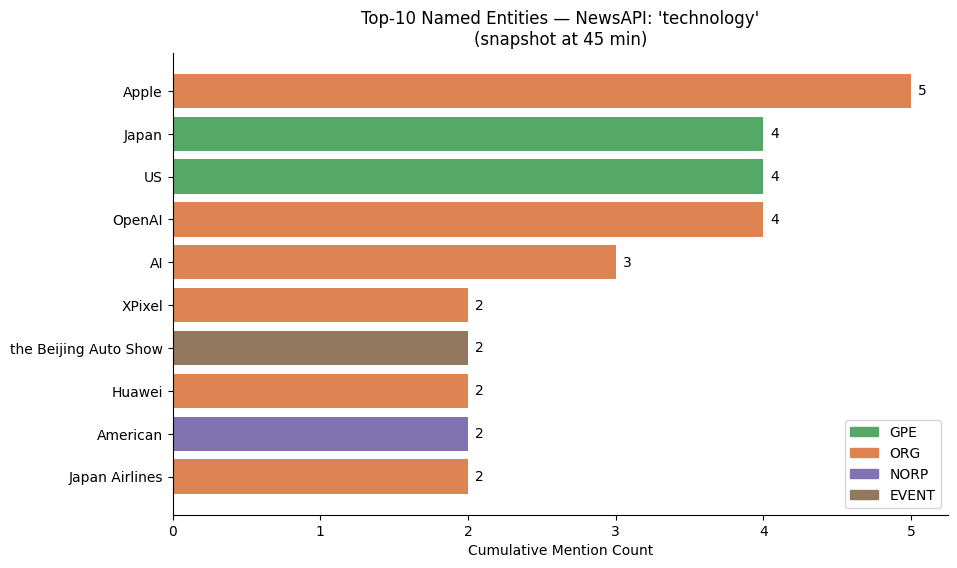

Waiting 15 min for next snapshot…



-- Snapshot @ 60 min --


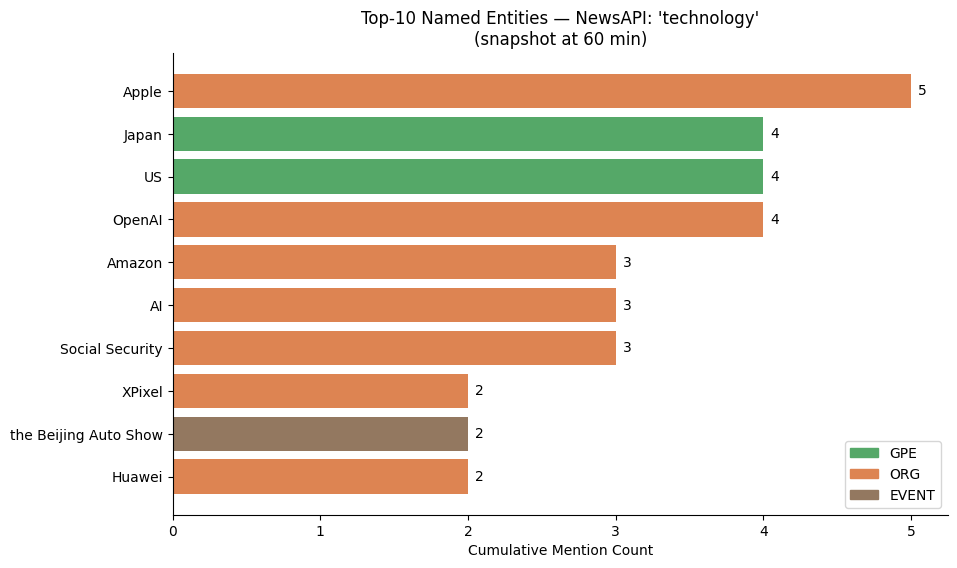


Saved final top-10 entities to top10_entities.json


In [ ]:
# Q1. Part C - Consumer & Matplotlib Visualizations (generate top10_entities_{N}min.png & top10_entities.json for Part D)

import json, time
import matplotlib.pyplot as plt
from kafka import KafkaConsumer

# Color palette by entity type — use this in your bar chart
PALETTE = {
    "PERSON":  "#4C72B0",
    "ORG":     "#DD8452",
    "GPE":     "#55A868",
    "LOC":     "#C44E52",
    "NORP":    "#8172B2",
    "EVENT":   "#937860",
    "PRODUCT": "#DA8BC3",
    "LAW":     "#8C8C8C",
}


def fetch_top10(bootstrap_servers="localhost:9092", topic="topic2"):
    ### TODO (1 of 2):
    consumer = KafkaConsumer(
        topic,
        bootstrap_servers=bootstrap_servers,
        auto_offset_reset='earliest',
        consumer_timeout_ms=8000,
        value_deserializer=lambda v: json.loads(v.decode("utf-8"))
    )
    entity_tracker = {}
    for msg in consumer:
        val = msg.value
        if val and val.get("entity"):
            # Overwrite earlier updates to only track the latest aggregate count
            entity_tracker[val["entity"]] = val
    consumer.close()
    # Sort descending by count and take top 10
    sorted_entities = sorted(entity_tracker.values(), key=lambda x: x["count"], reverse=True)
    return sorted_entities[:10]


def plot_top10(top10, interval_label, query_label, save_path=None):
    ### TODO (2 of 2):
    if not top10:
        print("No data available to plot yet.")
        return
    # Reverse the lists so the highest count is plotted at the top of the barh chart
    entities = [item["entity"] for item in top10][::-1]
    counts = [item["count"] for item in top10][::-1]
    labels = [item["label"] for item in top10][::-1]
    colors = [PALETTE.get(lbl, "#64B5CD") for lbl in labels]
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(entities, counts, color=colors)
    # Annotate bars with the exact counts
    for bar in bars:
        ax.annotate(str(bar.get_width()),
                    xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                    xytext=(5, 0),
                    textcoords="offset points",
                    ha='left', va='center')
    ax.set_xlabel("Cumulative Mention Count")
    ax.set_title(f"Top-10 Named Entities — NewsAPI: {query_label!r}\n(snapshot at {interval_label})")
    # Clean up the spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Build the legend using only the entity types present in the current top 10
    import matplotlib.patches as mpatches
    unique_labels = set(labels)
    legend_patches = [mpatches.Patch(color=PALETTE.get(lbl, "#64B5CD"), label=lbl) for lbl in unique_labels]
    ax.legend(handles=legend_patches, loc='lower right')
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


# ── Take snapshots at 15 / 30 / 45 / 60 minutes ──────────────────────────────
INTERVALS = [15, 30, 45, 60]
NEWS_QUERY = "technology" # Make sure this matches your producer
print("Waiting 15 minutes for the pipeline to process the first batch of news...")
time.sleep(15 * 60) # Wait 15 mins BEFORE the first snapshot
for i, minutes in enumerate(INTERVALS):
    label    = f"{minutes} min"
    save     = f"top10_entities_{minutes}min.png"
    print(f"\n-- Snapshot @ {label} --")
    top10 = fetch_top10()
    plot_top10(top10, label, query_label=NEWS_QUERY, save_path=save)
    if i < len(INTERVALS) - 1:
        wait_sec = (INTERVALS[i + 1] - minutes) * 60
        print(f"Waiting {wait_sec // 60} min for next snapshot…")
        time.sleep(wait_sec)
# After the 60-minute loop finishes, save the final top 10 to JSON for Part D
if top10:
    with open("top10_entities.json", "w") as f:
        json.dump(top10, f, indent=4)
    print("\nSaved final top-10 entities to top10_entities.json")


In [ ]:
# Q1. Part D - LLM Entity Enrichment
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.6 MB/s eta 0:00:00


In [ ]:
# "your_key_here" = ""
os.environ["GROQ_API_KEY"] = ""

In [ ]:
import os
import json
from groq import Groq

# 1. Load entities
def load_entities(path="top10_entities.json"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Error: The file {path} is missing. Run the 60-minute pipeline first.")

    with open(path, "r") as f:
        data = json.load(f)

    if not data:
        raise ValueError(f"Error: The file {path} is empty.")
    return data

# 2. Build prompt
def build_prompt(entity_name, entity_label, query):
    return (
        f"Given recent news about '{query}', why is the {entity_label} '{entity_name}' "
        f"prominently mentioned? Answer in 1-2 sentences focusing strictly on current events "
        f"and recent news context. Do not provide general background information."
    )

# 3. Enrich entity
def enrich_entity(client, entity_name, entity_label, query):
    prompt = build_prompt(entity_name, entity_label, query)

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": "You are a concise news analyst."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=200
    )
    return response.choices[0].message.content.strip()

# --- Execution ---
# Set your key: os.environ["GROQ_API_KEY"] = "your_key_here"
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
query_used = "technology"

try:
    top10_data = load_entities("top10_entities.json")

    with open("entity_enrichment.md", "w") as md_file:
        md_file.write(f"# Entity Enrichment Report: {query_used.capitalize()}\n\n")

        for item in top10_data:
            ent_name = item["entity"]
            ent_label = item["label"]

            print(f"Enriching: {ent_name} ({ent_label})...")
            summary = enrich_entity(client, ent_name, ent_label, query_used)

            md_file.write(f"### {ent_name} ({ent_label})\n")
            md_file.write(f"{summary}\n\n")

    print("✓ Enrichment complete. Saved to entity_enrichment.md")

except Exception as e:
    print(e)

Enriching: Apple (ORG)...
Enriching: Japan (GPE)...
Enriching: US (GPE)...
Enriching: OpenAI (ORG)...
Enriching: Amazon (ORG)...
Enriching: AI (ORG)...
Enriching: Social Security (ORG)...
Enriching: XPixel (ORG)...
Enriching: the Beijing Auto Show (EVENT)...
Enriching: Huawei (ORG)...
✓ Enrichment complete. Saved to entity_enrichment.md


---
## Section 4 — Cleanup (PROVIDED)
Stop all background processes.


In [ ]:
import signal

for proc, name in [(producer_proc, "NewsAPI producer"), (spark_proc, "Spark streaming")]:
    try:
        proc.send_signal(signal.SIGTERM)
        proc.wait(timeout=10)
        print(f"✓ {name} stopped")
    except Exception as e:
        print(f"  {name}: {e}")

KAFKA_DIR = "kafka_2.13-3.7.1"
!{KAFKA_DIR}/bin/kafka-server-stop.sh
print("✓ Kafka broker stopped")


✓ NewsAPI producer stopped
✓ Spark streaming stopped
✓ Kafka broker stopped


In [ ]:
print("=== producer.log (last 15 lines) ===")
!tail -n 15 producer.log

print("\n=== spark_streaming.log (last 20 lines) ===")
!tail -n 20 spark_streaming.log


=== producer.log (last 15 lines) ===

=== spark_streaming.log (last 20 lines) ===
  OpenAI                                   [ORG     ] count=4
  Japan                                    [GPE     ] count=4
  AI                                       [ORG     ] count=3
  Social Security                          [ORG     ] count=3
  Standard Intelligence Inc.               [ORG     ] count=2
  American                                 [NORP    ] count=2
  Spark Capital                            [ORG     ] count=2
26/05/02 01:37:14 WARN HDFSBackedStateStoreProvider: The state for version 10 doesn't exist in loadedMaps. Reading snapshot file and delta files if needed...Note that this is normal for the first batch of starting query.

[batch 10] Top-10 entities (2026-05-02T01:37:13.742596+00:00)
  Apple                                    [ORG     ] count=5
  US                                       [GPE     ] count=4
  AI                                       [GPE     ] count=4
  OpenAI      

### Q2. Reflection

**1. Query choice:**
I selected the query "technology" because I wanted to capture the fast-moving developments in the tech sector. I expected this query to surface major tech conglomerates (ORG), prominent CEOs or founders (PERSON), and regulatory bodies or geographic hubs (GPE/LOC) involved in recent software or hardware announcements.

**2. Results analysis:**
During the 60-minute window, the top-10 entities were dominated by Apple ORG, Japan, US GPEs. This reveals that the current news cycle is heavily focused on multinational tech giants and geographic hubs. It was somewhat surprising to see an American multinational technological organization rank highly, indicating that tech news is currently intersecting with big geopolitical nations.

**3. Prompt engineering:**
Initial prompt designs without strict constraints caused the LLM to output encyclopedia-style definitions rather than news context. By explicitly instructing the model to ground its answer in "recent news about technology" and adding the constraint to "focus strictly on current events," the LLM successfully transitioned from providing generic background info to delivering targeted, highly relevant context explaining the recent spike in mentions.